In [1]:
from pathlib import Path
import sys


def _find_repo_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / "pyproject.toml").exists() and (path / "pyresdmd").exists():
            return path
    raise RuntimeError("Could not find repo root containing pyproject.toml and pyresdmd/")


REPO_ROOT = _find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("Found pyresdmd root.")

Found pyresdmd root.


In [2]:
import numpy as np
import time
import torch
import matplotlib.pyplot as plt

from pyresdmd.compute.spectra import (
    compute_eigendecomposition_from_weights,
    compute_pseudospectra,
)
from pyresdmd.dicts.fourier_mode_dictionary import FourierModeDictionary
from pyresdmd.dicts.hermite_dictionary import HermiteDictionary
from pyresdmd.dicts import TensorProductDictionary
from pyresdmd.dicts.nn.relu.relu_dictionary import ReLUDictionary
from pyresdmd.dicts.trainable_dictionary import TrainableDictionary
from pyresdmd.utils.helpers import benchmark_metrics
from pyresdmd.utils.plotters import plot_curve, plot_pseudospec
from pyresdmd.sims.rossler import sim

print("Imports successful.")

Imports successful.


In [3]:
if torch.cuda.is_available():
    print("CUDA is available. Using GPU for computations.")
    device = torch.device("cuda")
else:
    print("No CUDA-supported device found. Using CPU for computations.")
    device = torch.device("cpu")

CUDA is available. Using GPU for computations.


In [4]:
dt = 0.01
a = 0.2
b = 0.2
c = 5.7
noise = 0.0
burn_in = 0
n_trajectories = 50
steps = 480
epochs = 1000
patience = 50
dictionary_size = 81

print("Simulation parameters set.")

Simulation parameters set.


In [5]:
def rand_point() -> torch.Tensor:
    '''Generates a random point in the state space. Samples uniformly from the box [-5, 5]^3.'''
    return 6*torch.rand(1, 3) - 3

initial_states = [rand_point() for _ in range(n_trajectories)]
x, y = sim(initial_states, dt = dt, a = a, b = b, c = c, steps = steps, noise = noise, burn_in = burn_in, device = device)

print("Trajectory data generated.")

Trajectory data generated.


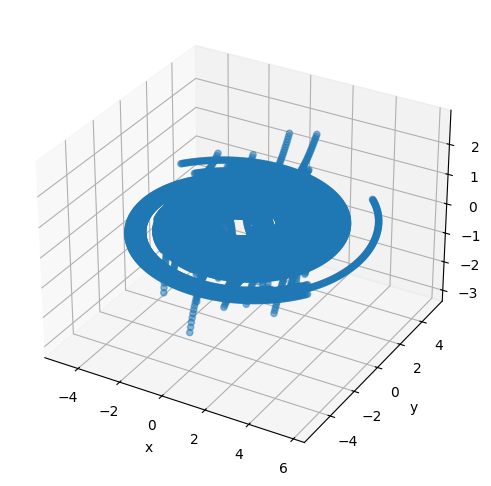

In [6]:
fig = plt.figure(figsize = (7, 6))
ax = fig.add_subplot(111, projection = '3d')

states = x.detach().cpu().numpy()
ax.scatter(
    states[:, 0],
    states[:, 1],
    states[:, 2],
    alpha = 0.5,
    s = 20,
)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()

Initial eigenvalues: tensor([0.9128+0.0000j, 0.9893+0.0854j, 0.9893-0.0854j, 0.9925+0.0813j,
        0.9925-0.0813j, 0.9858+0.0798j, 0.9858-0.0798j, 0.9942+0.0727j,
        0.9942-0.0727j, 0.9812+0.0706j, 0.9812-0.0706j, 0.9959+0.0649j,
        0.9959-0.0649j, 0.9831+0.0618j, 0.9831-0.0618j, 0.9972+0.0578j,
        0.9972-0.0578j, 0.9893+0.0607j, 0.9893-0.0607j, 0.9752+0.0526j,
        0.9752-0.0526j, 0.9479+0.0170j, 0.9479-0.0170j, 0.9636+0.0398j,
        0.9636-0.0398j, 0.9987+0.0492j, 0.9987-0.0492j, 0.9839+0.0522j,
        0.9839-0.0522j, 0.9493+0.0000j, 0.9601+0.0299j, 0.9601-0.0299j,
        0.9998+0.0395j, 0.9998-0.0395j, 0.9811+0.0401j, 0.9811-0.0401j,
        0.9624+0.0171j, 0.9624-0.0171j, 0.9816+0.0377j, 0.9816-0.0377j,
        0.9946+0.0364j, 0.9946-0.0364j, 0.9904+0.0362j, 0.9904-0.0362j,
        1.0005+0.0297j, 1.0005-0.0297j, 0.9861+0.0365j, 0.9861-0.0365j,
        0.9631+0.0000j, 0.9935+0.0328j, 0.9935-0.0328j, 0.9804+0.0259j,
        0.9804-0.0259j, 1.0007+0.0201j, 1.0

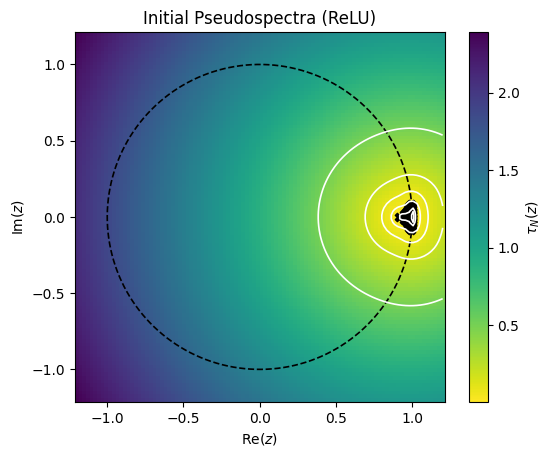

In [7]:
# generates trainable dictionary and computes initial metrics.
base = ReLUDictionary(input_dim = 3, n_functions = dictionary_size)
dictionary = TrainableDictionary(base)
dictionary.to(device)

with torch.no_grad():
    report = dictionary.report(x, y)
    Psi_X, Psi_Y = dictionary.evaluate(x), dictionary.evaluate(y)
init_eigvals = report['eigenvalues']
init_loss = report['loss']
init_cond_num = report['cond_num']
init_forecast_error = report['forecast_error']
init_pseudospec = compute_pseudospectra(Psi_X, Psi_Y)
del Psi_X, Psi_Y, report
eps_levels = [1e-3, 2e-3, 5e-3, 1e-2, 2e-2, 5e-2, 1e-1, 2e-1, 5e-1]

print(f"Initial eigenvalues: {init_eigvals}")
print(f"Initial loss: {init_loss}")
print(f"Initial condition number: {init_cond_num}")
print(f"Initial forecast error: {init_forecast_error}")

re_vals = init_pseudospec['re_vals']
im_vals = init_pseudospec['im_vals']
tau_grid = init_pseudospec['tau_grid']

plot_pseudospec(re_vals, im_vals, tau_grid, eps_levels, unit_circle = True, eigvals = init_eigvals, displayname = 'Initial Pseudospectra (ReLU)', save = False)
del re_vals, im_vals, tau_grid, init_pseudospec

Hermite eigvals: tensor([0.9114+0.2258j, 0.9114-0.2258j, 0.8854+0.2058j, 0.8854-0.2058j,
        0.8926+0.1769j, 0.8926-0.1769j, 0.9361+0.1603j, 0.9361-0.1603j,
        0.9407+0.1599j, 0.9407-0.1599j, 0.8874+0.1401j, 0.8874-0.1401j,
        0.8152+0.0000j, 0.8386+0.0788j, 0.8386-0.0788j, 0.8444+0.0715j,
        0.8444-0.0715j, 0.8762+0.1112j, 0.8762-0.1112j, 0.8891+0.1187j,
        0.8891-0.1187j, 0.8308+0.0092j, 0.8308-0.0092j, 0.9301+0.1320j,
        0.9301-0.1320j, 0.9460+0.1315j, 0.9460-0.1315j, 0.8978+0.1138j,
        0.8978-0.1138j, 0.8763+0.0914j, 0.8763-0.0914j, 0.9096+0.1095j,
        0.9096-0.1095j, 0.9417+0.1065j, 0.9417-0.1065j, 0.9310+0.1055j,
        0.9310-0.1055j, 0.8935+0.0749j, 0.8935-0.0749j, 0.8626+0.0000j,
        0.8741+0.0000j, 0.9610+0.0973j, 0.9610-0.0973j, 0.9285+0.0964j,
        0.9285-0.0964j, 0.8798+0.0402j, 0.8798-0.0402j, 0.9486+0.0884j,
        0.9486-0.0884j, 0.9542+0.0872j, 0.9542-0.0872j, 0.9323+0.0788j,
        0.9323-0.0788j, 0.8881+0.0182j, 0.8881-

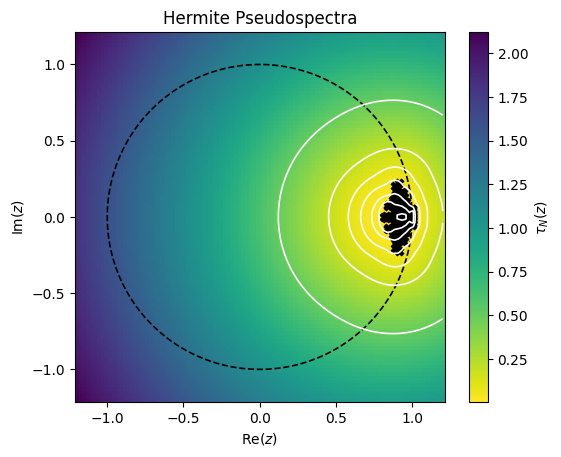

In [8]:
# generates benchmark dictionary and gives statistics
size = int(dictionary_size**(1/3))
eps_levels = [1e-3, 2e-3, 5e-3, 1e-2, 2e-2, 5e-2, 1e-1, 2e-1, 5e-1]
hermite_dict = TensorProductDictionary(HermiteDictionary(size), HermiteDictionary(size), HermiteDictionary(size))
hermite_dict.to(device)
with torch.no_grad():
    hermite_metrics = benchmark_metrics(hermite_dict, x, y)
hermite_eigvals = hermite_metrics['Lambda']
hermite_cond_num = hermite_metrics['cond_num']
hermite_loss = hermite_metrics['loss']
hermite_forecast_error = hermite_metrics['forecast_error']
hermite_pseudospec = hermite_metrics['pseudospec']

print(f"Hermite eigvals: {hermite_eigvals}")
print(f"Hermite loss: {hermite_loss}")
print(f"Hermite condition number: {hermite_cond_num}")
print(f"Hermite forecast error: {hermite_forecast_error}")

re_vals = hermite_pseudospec['re_vals']
im_vals = hermite_pseudospec['im_vals']
tau_grid = hermite_pseudospec['tau_grid']
plot_pseudospec(re_vals, im_vals, tau_grid, eps_levels, unit_circle = True, eigvals = hermite_eigvals, displayname = 'Hermite Pseudospectra', save = False)
del re_vals, im_vals, tau_grid, hermite_pseudospec

Best loss: 0.0006493921391665936
Condition number of best model: 498.2064208984375
Forecast error of best model: 4.023539986519609e-06


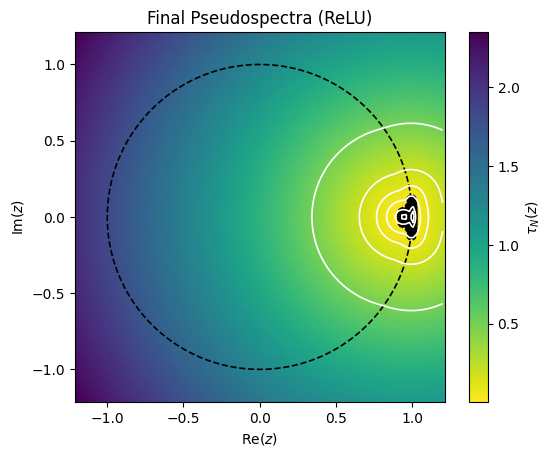

In [9]:
trained = dictionary.fit(x, y, epochs = epochs, patience = patience)
train_losses = trained['train_losses']
test_losses = trained['test_losses']
train_cond_nums = trained['train_cond_nums']
test_cond_nums = trained['test_cond_nums'] 
train_forecast_errors = trained['train_forecast_errors']
test_forecast_errors = trained['test_forecast_errors']
final_epoch = trained['final_epoch']

with torch.no_grad():
    best_report = dictionary.report(x, y)
    Psi_X, Psi_Y = dictionary.evaluate(x), dictionary.evaluate(y)
best_loss = best_report['loss']
best_cond_num = best_report['cond_num']
best_forecast_error = best_report['forecast_error']
final_pseudospec = compute_pseudospectra(Psi_X, Psi_Y)
W = torch.ones(x.shape[0], device = x.device) / x.shape[0]
final_eigvals, _ = compute_eigendecomposition_from_weights(Psi_X, Psi_Y, W)
del Psi_X, Psi_Y

print(f"Best loss: {best_loss}")
print(f"Condition number of best model: {best_cond_num}")
print(f"Forecast error of best model: {best_forecast_error}")
re_vals = final_pseudospec['re_vals']
im_vals = final_pseudospec['im_vals']
tau_grid = final_pseudospec['tau_grid']
plot_pseudospec(re_vals, im_vals, tau_grid, eps_levels, unit_circle = True, eigvals = final_eigvals, displayname = 'Final Pseudospectra (ReLU)', save = False)
del re_vals, im_vals, tau_grid, final_pseudospec

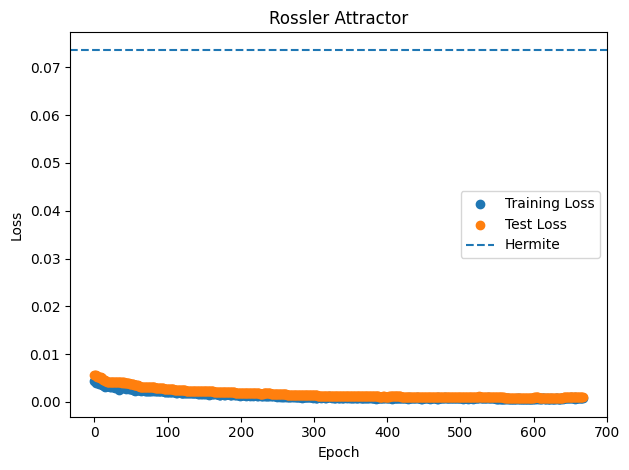

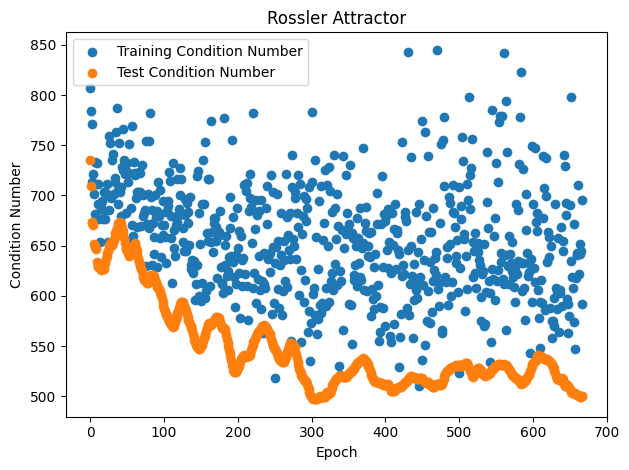

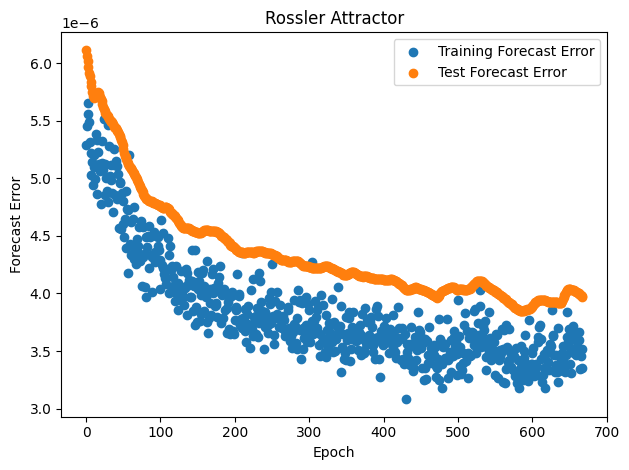

In [10]:
show_hermite_cond_num = False 
show_hermite_loss = True 
show_hermite_forecast_error = False

add_values_loss = {'Hermite': hermite_loss} if show_hermite_loss else {}
add_values_cond_num = {'Hermite': hermite_cond_num} if show_hermite_cond_num else {}
add_values_forecast_error = {'Hermite': hermite_forecast_error} if show_hermite_forecast_error else {}

plot_curve(final_epoch, train_losses, test_losses, add_values = add_values_loss, 
                       displayname = 'Rossler Attractor', ylabel = 'Loss', save_plot = False)

plot_curve(final_epoch, train_cond_nums, test_cond_nums, add_values = add_values_cond_num,
                        displayname = 'Rossler Attractor', ylabel = 'Condition Number', save_plot = False)

plot_curve(final_epoch, train_forecast_errors, test_forecast_errors, add_values = add_values_forecast_error,
                        displayname = 'Rossler Attractor', ylabel = 'Forecast Error', save_plot = False)